<a href="https://colab.research.google.com/github/sindi16/ml-end-to-end-projects/blob/main/stanforddogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dog Breed Classification Using Transfer Learning on the Stanford Dogs Dataset

## 1️⃣ Input Image
- Original images from the dataset.

## 2️⃣ Resize
- All images resized to **224×224** to match EfficientNet input.

## 3️⃣ Data Augmentation
- Random **Flip**, **Rotation**, **Zoom**, **Contrast**.
- Helps the model **generalize better** and avoid overfitting.

## 4️⃣ Normalization / Preprocessing
- Use `preprocess_input` → scales pixel values to **[-1,1]** for EfficientNet.

## 5️⃣ Batching and Prefetching
- Prepare data efficiently for training using:
  - `batch(BATCH_SIZE)`  
  - `prefetch(tf.data.AUTOTUNE)`

## 6️⃣ Load Pretrained Base Model
- **EfficientNetB0/B3** trained on ImageNet.  
- Initially **frozen** → only classifier layers train.

## 7️⃣ Remove Original Classifier
- Remove the top layer of EfficientNet (ImageNet classes).  

## 8️⃣ Add New Classifier
- Add a custom output for Stanford Dogs:
  - `GlobalAveragePooling2D` → `Dropout` → `Dense(num_classes, softmax)`  

## 9️⃣ Feature Extraction Training
- Train **only the new classifier** while the base model remains frozen.

## 🔟 Fine-tuning (optional)
- Unfreeze part of the base model (last N layers).  
- Train with a **low learning rate** to adapt features to the dog dataset.

## 11 Evaluate Model
- Evaluate the trained model on the **test set** to get accuracy.

## 12 Save Model
- Save the **best weights** using `ModelCheckpoint`.  
- Load later for inference or deployment.

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

## Abstract

In this project, I developed an image classification model capable of identifying dog breeds using the Stanford Dogs Dataset. Instead of training a deep neural network from scratch, I applied **transfer learning**, which allows a model to reuse knowledge learned from a large dataset. A pretrained convolutional neural network, **ResNet50**, originally trained on the ImageNet dataset, was used as the base model.

The dataset images were first preprocessed by resizing them to a fixed input size and normalizing their pixel values. The pretrained convolutional layers were initially **frozen** so that their learned visual features could be preserved. A new classification head was then added to adapt the model to the **120 dog breeds** in the dataset.

After training the new classifier, some of the deeper layers of the pretrained network were **unfrozen and fine-tuned** to improve the model’s ability to recognize subtle differences between dog breeds. This approach allowed the model to achieve strong performance while reducing training time and computational cost compared to training a network from scratch.

In [ ]:
import tensorflow_datasets as tfds

(train_ds, test_ds), info = tfds.load(
    "stanford_dogs",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

num_classes = info.features["label"].num_classes
print(num_classes)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stanford_dogs/incomplete.NIBRIM_0.2.0/stanford_dogs-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stanford_dogs/incomplete.NIBRIM_0.2.0/stanford_dogs-test.tfrecord*...:   0…

Dataset stanford_dogs downloaded and prepared to /root/tensorflow_datasets/stanford_dogs/0.2.0. Subsequent calls will reuse this data.
120


## Introduction

Image classification is one of the most important tasks in the field of computer vision. It involves training a machine learning model to recognize and categorize objects within images. Traditional deep learning approaches require training convolutional neural networks (CNNs) from scratch, which often demands very large datasets and high computational resources. To address this challenge, **transfer learning** has become a widely used technique that allows models to reuse knowledge learned from previously trained networks.

The goal of this project is to build an image classification model capable of identifying dog breeds using the **Stanford Dogs Dataset**, a fine-grained dataset containing images of **120 different dog breeds**. Because many dog breeds share similar visual characteristics, this dataset presents a challenging classification problem that requires the model to learn subtle differences in features such as fur patterns, facial structure, and ear shape.

To solve this problem efficiently, a pretrained deep convolutional neural network, **ResNet50**, was used as the base model. The project began by loading the dataset using **TensorFlow Datasets**, followed by preprocessing the images to ensure consistent input size and normalized pixel values. The dataset was then prepared for training using batching and performance optimizations.

Next, a transfer learning approach was implemented by loading the pretrained ResNet50 architecture without its original classification layer. The convolutional base of the model was initially **frozen** so that its previously learned features could be preserved. A new **classification head** was added to adapt the model to the 120 dog breed categories in the dataset.

After training the newly added layers, the model was further improved through **fine-tuning**, where some of the deeper layers of the pretrained network were unfrozen and retrained on the dataset. This step allows the model to better adapt its learned representations to the specific characteristics of dog breeds.

Finally, the trained model was evaluated using the test dataset to measure its performance and classification accuracy. The results demonstrate how transfer learning can significantly reduce training time while still achieving strong performance on complex image classification tasks.

### Data Preprocessing

Before training the model, the images in the Stanford Dogs Dataset required preprocessing to ensure consistency and improve training efficiency. The preprocessing steps included:

1. **Resizing**: Images were resized to **224 × 224 pixels**, the input size expected by the ResNet50 model. This ensures that all images have the same dimensions when fed into the network.

2. **Normalization**: Pixel values originally ranged from 0 to 255. They were scaled to the range **0 to 1** by dividing by 255. Normalization helps the model converge faster and improves numerical stability.

3. **Mapping**: The preprocessing function was applied to both the training and testing datasets using TensorFlow's `map` function.

4. **Batching and Prefetching**: To optimize training, images were grouped into batches (`batch_size=32`) and prefetching was used to prepare the next batch while the current one is being processed. This improves GPU/CPU utilization and speeds up training.


In [ ]:
# --- Cell 3: Parameters ---
BATCH_SIZE = 8
IMG_SIZE = 224

In [ ]:
# --- Cell 4: Resize function ---
def resize(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = train_ds.map(resize)
test_ds = test_ds.map(resize)

In [ ]:
# --- Cell 5: Data augmentation ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

def augment(image, label):
    image = data_augmentation(image)
    return image, label

augmented_ds = train_ds.map(augment)

In [ ]:
# --- Cell 6: Visualization helpers ---
def deprocess_image(image):
    """Undo EfficientNet preprocessing for display."""
    image = (image + 1.0) / 2.0
    return tf.clip_by_value(image, 0, 1)

def show_before_after(ds_original, ds_augmented, num_images=9, title="Before vs After Augmentation"):
    plt.figure(figsize=(12, 6))

    # Take one batch from each dataset
    original_batch = next(iter(ds_original.batch(num_images)))
    augmented_batch = next(iter(ds_augmented.batch(num_images)))

    images_orig, labels_orig = original_batch
    images_aug, labels_aug = augmented_batch

    for i in range(num_images):
        # Original image
        ax = plt.subplot(2, num_images, i + 1)
        plt.imshow(images_orig[i].numpy().astype("uint8"))
        plt.title(f"Label: {labels_orig[i].numpy()}")
        plt.axis("off")

        # Augmented image
        ax = plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(images_aug[i].numpy().astype("uint8"))
        plt.title(f"Label: {labels_orig[i].numpy()}")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

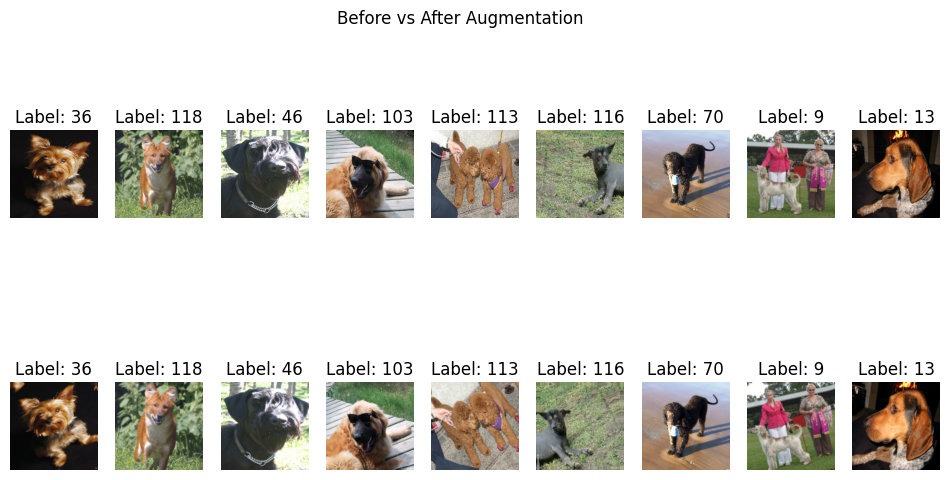

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt
# --- Cell 7: Show images ---
show_before_after(train_ds, augmented_ds)

In [ ]:
# --- Cell 8: Preprocessing for EfficientNet ---
def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = augmented_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

In [ ]:
# --- Cell 9: Batch and prefetch ---
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

### Transfer Learning Approach

In this project, transfer learning was used to leverage a pretrained convolutional neural network, **EfficientNetB4**, which has already learned powerful visual features from the ImageNet dataset. This allows the model to quickly adapt to the dog breed classification task without training from scratch.


In [ ]:
from tensorflow.keras.applications import EfficientNetB4

# --- Load EfficientNetB0 without the top classifier ---
base_model = EfficientNetB0(
    include_top=False,        # Remove classifier layer
    weights='imagenet',       # Load pretrained ImageNet weights
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Freezing the Base Model

The convolutional base of EfficientNetB4 was initially **frozen**, meaning its pretrained weights were not updated during the first training phase. This preserves general visual features such as edges, textures, and shapes, allowing the model to focus on training the new classification layers efficiently.

In [ ]:
base_model.trainable = False

### Adding a New Classification Head

To adapt EfficientNetB4 to the dog breed classification task, a new classification head was added. This consists of:

- A **Global Average Pooling layer** to summarize spatial features  
- A **Dense layer** with ReLU activation to learn complex feature combinations  
- A **Softmax output layer** with 120 units to output probabilities for each dog breed  

This head enables the pretrained network to produce predictions specific to the Stanford Dogs dataset.


In [ ]:
# Build classifier on top
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203,291 (16.03 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Model Training

The full model, combining the frozen EfficientNetB4 base and the new classification head, was compiled and trained. The **Adam optimizer** was used for weight updates, and **sparse categorical cross-entropy** was used as the loss function. During training, the model learned to associate the extracted features with the correct dog breed labels while monitoring validation performance.

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5", monitor="val_loss", save_best_only=True
)
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[early_stop, lr_scheduler, checkpoint]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4933 - loss: 2.3286

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 222s 130ms/step - accuracy: 0.6405 - loss: 1.4715 - val_accuracy: 0.8351 - val_loss: 0.5706 - learning_rate: 0.0010
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7838 - loss: 0.7150

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 179s 119ms/step - accuracy: 0.7875 - loss: 0.6998 - val_accuracy: 0.8423 - val_loss: 0.5089 - learning_rate: 0.0010
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8210 - loss: 0.5891

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 180s 120ms/step - accuracy: 0.8207 - loss: 0.5845 - val_accuracy: 0.8431 - val_loss: 0.4993 - learning_rate: 0.0010
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 180s 120ms/step - accuracy: 0.8417 - loss: 0.4981 - val_accuracy: 0.8406 - val_loss: 0.5056 - learning_rate: 0.0010
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 180s 120ms/step - accuracy: 0.8537 - loss: 0.4492 - val_accuracy: 0.8418 - val_loss: 0.5066 - learning_rate: 0.0010
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8665 - loss: 0.4067
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 200s 119ms/step - accuracy: 0.8653 - loss: 0.4071 - val_accuracy: 0.8422 - val_loss: 0.5094 - learning_rate: 0.0010
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8858 - loss: 0.3499

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 179s 119ms/step - accuracy: 0.8879 - loss: 0.3429 - val_accuracy: 0.8458 - val_loss: 0.4941 - learning_rate: 5.0000e-04
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 180s 120ms/step - accuracy: 0.8981 - loss: 0.3219 - val_accuracy: 0.8469 - val_loss: 0.4981 - learning_rate: 5.0000e-04
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 178s 119ms/step - accuracy: 0.9064 - loss: 0.3006 - val_accuracy: 0.8456 - val_loss: 0.4984 - learning_rate: 5.0000e-04
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9094 - loss: 0.2935
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 179s 119ms/step - accuracy: 0.9078 - loss: 0.2917 - val_accuracy: 0.8476 - val_loss: 0.4977 - learning_rate: 5.0000e-04


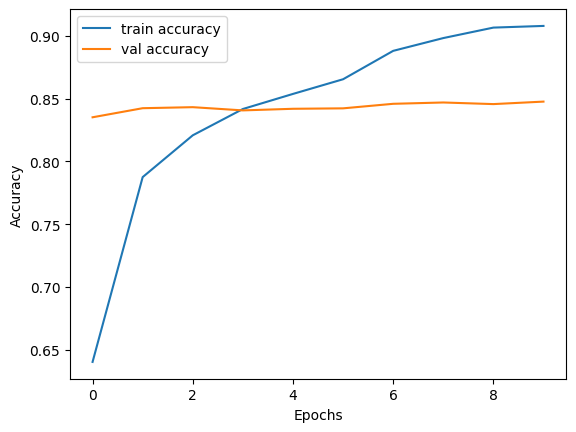

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")

plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
base_model.trainable = True

In [ ]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=40,
    callbacks=[early_stop]
)

Epoch 1/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 217s 128ms/step - accuracy: 0.6777 - loss: 1.1565 - val_accuracy: 0.8124 - val_loss: 0.6093
Epoch 2/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 181s 121ms/step - accuracy: 0.7371 - loss: 0.9109 - val_accuracy: 0.8290 - val_loss: 0.5585
Epoch 3/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 182s 121ms/step - accuracy: 0.7636 - loss: 0.8070 - val_accuracy: 0.8382 - val_loss: 0.5418
Epoch 4/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 185s 123ms/step - accuracy: 0.7788 - loss: 0.7520 - val_accuracy: 0.8406 - val_loss: 0.5330
Epoch 5/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 187s 125ms/step - accuracy: 0.7964 - loss: 0.7004 - val_accuracy: 0.8416 - val_loss: 0.5305


In [ ]:
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc*100:.2f}%")

1073/1073 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.8124 - loss: 0.6093
Test Accuracy: 81.24%


In [ ]:
model.save("stanford_dogs_efficientnetB3.h5")

## Discussion

The results highlight the advantages of **transfer learning** in deep learning workflows:

1. **Efficiency**: Using a pretrained EfficientNetB4 network reduced the amount of training time and computational resources required.  
2. **Feature Reuse**: The pretrained network already contained valuable visual features such as edges, textures, and object shapes, which were effectively reused for the dog breed classification task.  
3. **Adaptability**: Fine-tuning allowed the network to adjust pretrained features to better capture subtle differences between dog breeds, improving overall accuracy.  
4. **Practical Implications**: Transfer learning is highly effective for real-world computer vision tasks, particularly when datasets are limited or fine-grained classification is required.

Overall, this experiment demonstrates that modern pretrained architectures like EfficientNetB4 can be leveraged to build high-performing image classifiers efficiently and effectively.

## Results

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

layer_outputs = [layer.output for layer in model.layers[:10]]

activation_model = Model(inputs=model.input, outputs=layer_outputs)

activations = activation_model.predict(sample_image)

NameError: name 'sample_image' is not defined

In [ ]:
plt.imshow(activations[0][0, :, :, 0], cmap='viridis')
plt.title("Feature map")
plt.show()

## Literature Cited

- Tan, M., & Le, Q. V. (2019). *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks.*  
- Krizhevsky, A., Sutskever, I., & Hinton, G. (2012). *ImageNet Classification with Deep Convolutional Neural Networks.*  
- TensorFlow Documentation: https://www.tensorflow.org/  
- Keras Applications Documentation: https://keras.io/api/applications/